# Atelier 3 — Segmentation non supervisée des véhicules

L’objectif du clustering est de comprendre la structure interne du catalogue de véhicules sans utiliser de cible. On cherche des groupes de véhicules semblables en termes de puissance, de masse et d’émissions, puis on les décrit à partir des variables catégorielles comme l’énergie et l’hybridation.

## 1. Préparation des variables utiles

Pour le clustering, les variables retenues doivent être pertinentes et non redondantes. Ici, on garde la puissance maximale, la masse minimale et la cible de CO2. `conso_mixte` est exclue parce qu’elle est quasi redondante avec le CO2 et risque d’alourdir le modèle sans ajout de signal.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../donnees_nettoyees/vehicules_analyse_conso_co2.csv", sep=";", encoding="utf-8-sig")
df.columns = df.columns.str.strip().str.lower()
for col in ["cnit", "lib_mrq_doss", "lib_mod_doss", "energ", "hybride", "typ_boite_nb_rapp"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

df["famille"] = df["lib_mrq_doss"].fillna("").astype(str) + " | " + df["lib_mod_doss"].fillna("").astype(str)
features = ["puiss_max", "masse_ordma_min", "co2_mixte"]
X = df[features].copy()
print("Shape du dataset clustering :", X.shape)
display(X.head())
print("Corrélation `conso_mixte` / `co2_mixte` :", round(df[["conso_mixte", "co2_mixte"]].corr().iloc[0, 1], 4))

Shape du dataset clustering : (20824, 3)


,puiss_max,masse_ordma_min,co2_mixte
0,147.0,1505,182.0
1,147.0,1555,186.0
2,100.0,1565,134.0
3,100.0,1565,134.0
4,100.0,1615,137.0


Corrélation `conso_mixte` / `co2_mixte` : 0.9763


## 2. Standardisation

KMeans est très sensible aux échelles de variables. La standardisation est donc obligatoire pour équilibrer l’influence de la puissance, de la masse et des émissions. Sans cette étape, les variables à grande amplitude domineraient le clustering.

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

[[ 0.0114176  -0.82253472  0.6196134 ]
 [ 0.0114176  -0.68802028  0.7100162 ]
 [-0.57526228 -0.6611174  -0.46522015]
 [-0.57526228 -0.6611174  -0.46522015]
 [-0.57526228 -0.52660296 -0.39741806]]


## 3. Choix du nombre de clusters : coude et silhouette

On teste plusieurs valeurs de K de 2 à 10. La courbe du coude montre la baisse de l’inertie lorsque K augmente. Le score de silhouette mesure quant à lui la qualité du partitionnement. Le K final doit être choisi sur la base des deux critères, ainsi que de l’interprétabilité métier.

Inertie par cluster :


,k,inertie
0,2,34971.966778
1,3,20108.336441
2,4,15015.306734
3,5,12600.531058
4,6,10687.139366
5,7,9417.057417
6,8,8464.273055
7,9,7749.990211
8,10,7148.305137



Silhouette par cluster :


,k,silhouette
0,2,0.441366
1,3,0.472628
2,4,0.410435
3,5,0.383937
4,6,0.354798
5,7,0.354967
6,8,0.342897
7,9,0.346672
8,10,0.354860


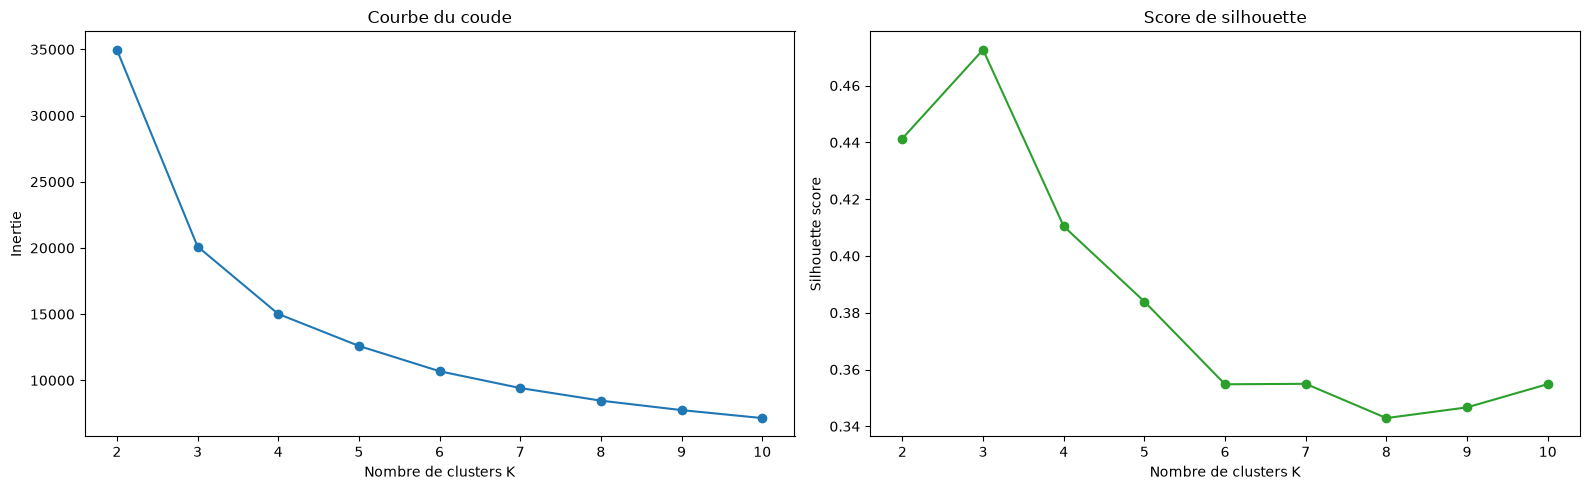

In [3]:
inertia = []
silhouette_scores = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = model.fit_predict(X_scaled)
    inertia.append((k, model.inertia_))
    silhouette_scores.append((k, silhouette_score(X_scaled, labels)))

inertia_df = pd.DataFrame(inertia, columns=["k", "inertie"])
silhouette_df = pd.DataFrame(silhouette_scores, columns=["k", "silhouette"])
print("Inertie par cluster :")
display(inertia_df)
print("\nSilhouette par cluster :")
display(silhouette_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(inertia_df["k"], inertia_df["inertie"], marker="o")
axes[0].set_title("Courbe du coude")
axes[0].set_xlabel("Nombre de clusters K")
axes[0].set_ylabel("Inertie")

axes[1].plot(silhouette_df["k"], silhouette_df["silhouette"], marker="o", color="tab:green")
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("Nombre de clusters K")
axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()

**Interprétation.** Le meilleur score de silhouette est obtenu pour K=3 (0,4726), devant K=2 (0,4414) ; à partir de K=4, le score baisse à 0,4104 puis continue globalement à diminuer. La courbe d’inertie baisse fortement de 34 971,97 à K=2 à 20 108,34 à K=3, puis plus progressivement. K=3 est donc un compromis défendable entre séparation statistique, coude et lisibilité métier ; cette sélection n’est pas une preuve qu’il existe exactement trois catégories naturelles.

## 4. Ajustement du modèle final

Le nombre de clusters final est choisi après comparaison du coude, du score de silhouette et de l’interprétabilité métier. Il faut éviter un K trop élevé qui produirait des groupes trop petits et moins exploitables.

In [4]:
k_final = int(silhouette_df.loc[silhouette_df['silhouette'].idxmax(), 'k'])
model = KMeans(n_clusters=k_final, n_init=10, random_state=42)
labels = model.fit_predict(X_scaled)
df['cluster'] = labels
print("K retenu :", k_final)
print("Clusters obtenus :", sorted(df["cluster"].unique().tolist()))
print("Taille des clusters :")
print(df["cluster"].value_counts().sort_index().to_string())

K retenu : 3
Clusters obtenus : [0, 1, 2]
Taille des clusters :
cluster
0     7964
1     1801
2    11059


## 5. Profil moyen des clusters

L’étape suivante consiste à décrire les groupes obtenus à partir de leurs caractéristiques moyennes et de la répartition des variables catégorielles. Cela permet d’émettre une interprétation métier : quels types de véhicules forment chaque cluster ?

In [5]:
cluster_profile = df.groupby("cluster")[["puiss_max", "masse_ordma_min", "co2_mixte", "puiss_admin"]].mean(numeric_only=True)
display(cluster_profile.round(2))
print("\nDistribution de l’énergie par cluster :")
display(pd.crosstab(df["cluster"], df["energ"]))
print("\nDistribution de l’hybridation par cluster :")
display(pd.crosstab(df["cluster"], df["hybride"]))

,puiss_max,masse_ordma_min,co2_mixte,puiss_admin
cluster,,,,
0,139.19,2146.96,176.87,11.70
1,363.24,1977.37,244.59,40.10
2,115.68,1541.48,123.88,8.43



Distribution de l’énergie par cluster :


energ,EE,EH,ES,ES/GN,ES/GP,FE,GH,GL,GN,GN/ES,GO,GP/ES
cluster,,,,,,,,,,,,
0,2,243,1179,16,0,1,127,0,40,0,6356,0
1,2,53,1733,0,0,0,0,0,0,0,13,0
2,86,250,4022,36,21,0,259,1,21,36,6306,21



Distribution de l’hybridation par cluster :


hybride,non,oui
cluster,,
0,7592,372
1,1746,55
2,10463,596


**Interprétation.** Le cluster 1 est le groupe de véhicules les plus puissants (363,24 de puissance maximale) et les plus émetteurs (244,59 de CO2), tandis que le cluster 2 regroupe les véhicules les moins puissants (115,68) et les moins émetteurs (123,88). Le cluster 0 est intermédiaire en puissance (139,19), mais plus lourd en moyenne (2 146,96 kg) et émet 176,87 g/km. Les tailles sont déséquilibrées (11 059, 7 964 et 1 801 lignes) et les distributions d’énergie restent dominées par `ES` et `GO` ; les clusters décrivent donc surtout les variables techniques retenues, pas nécessairement des familles commerciales.

## 6. Visualisation 2D : ACP et nuage de points

Une projection PCA en 2 dimensions donne une vue synthétique de la structure. On la colore par cluster pour vérifier si les groupes sont bien distincts et interprétables. En complément, on peut explorer un nuage de points sur deux variables réelles, par exemple puissance et CO2.

Variance expliquée :
{'PC1': np.float64(0.6708), 'PC2': np.float64(0.2621)}


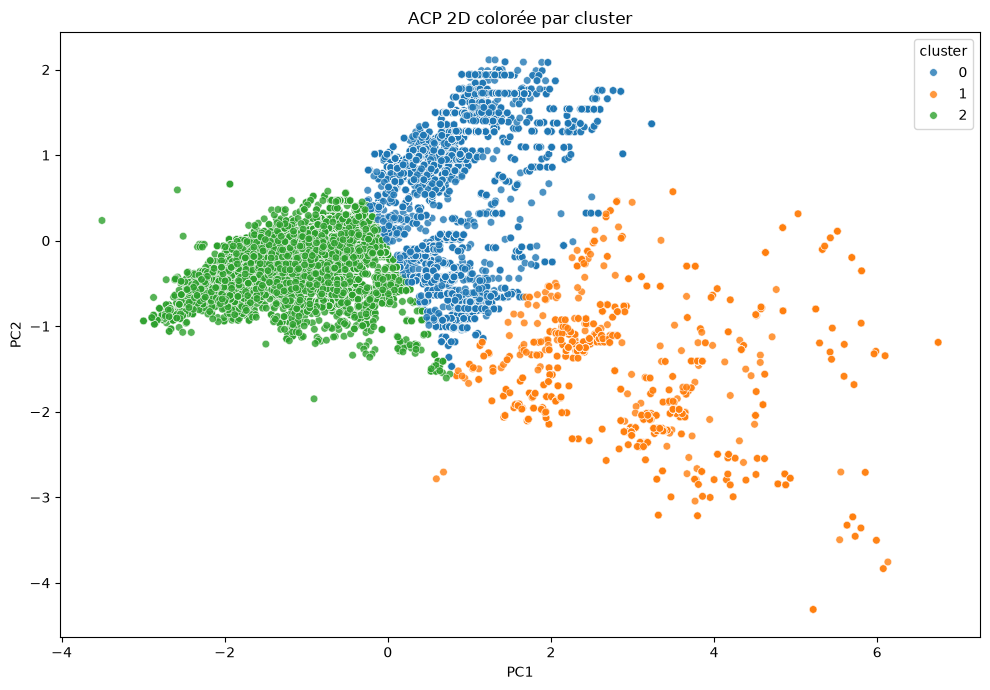

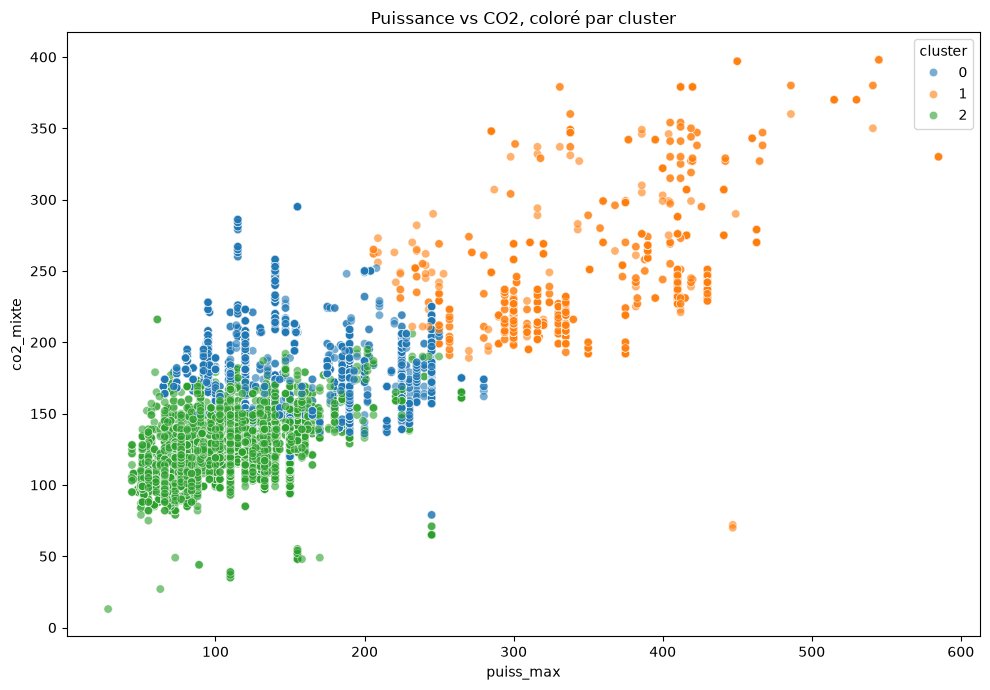

In [6]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = labels

print("Variance expliquée :")
print({
    "PC1": round(pca.explained_variance_ratio_[0], 4),
    "PC2": round(pca.explained_variance_ratio_[1], 4),
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="tab10", s=30, alpha=0.8)
plt.title("ACP 2D colorée par cluster")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="puiss_max", y="co2_mixte", hue="cluster", palette="tab10", alpha=0.6)
plt.title("Puissance vs CO2, coloré par cluster")
plt.tight_layout()
plt.show()

**Interprétation.** Les deux premiers axes expliquent 67,08 % et 26,21 % de la variance, soit 93,29 % cumulés. La projection 2D conserve donc l’essentiel de la structure des trois variables standardisées et permet de visualiser les groupes. Elle ne constitue toutefois pas une mesure supplémentaire de qualité : des points peuvent se chevaucher dans la projection, et la séparation doit être lue avec le score de silhouette, les profils moyens et les effectifs. La PCA ne permet pas non plus d’attribuer une cause aux différences entre clusters.

## 7. Sensibilité aux quasi-doublons

On vérifie la stabilité de la segmentation quand on plafonne les familles à 50 variantes. Cela permet de détecter l’effet des familles très denses ou des quasi-doublons sur les clusters.

In [7]:
def cap_families(df, max_per_family=50, random_state=42):
    rng = np.random.RandomState(random_state)
    out = []
    for fam, fam_df in df.groupby("famille"):
        sample = fam_df.sample(n=min(len(fam_df), max_per_family), random_state=rng.randint(0, 10_000))
        out.append(sample)
    return pd.concat(out, axis=0)

df_cap = cap_families(df, max_per_family=50, random_state=42)
X_cap = df_cap[features].copy()
X_cap_scaled = StandardScaler().fit_transform(X_cap)
model_cap = KMeans(n_clusters=k_final, n_init=10, random_state=42)
labels_cap = model_cap.fit_predict(X_cap_scaled)
df_cap['cluster'] = labels_cap
print("Clusters sur jeu plafonné :")
print(df_cap['cluster'].value_counts().sort_index().to_string())
print("\nProfil sur jeu plafonné :")
display(df_cap.groupby('cluster')[features].mean(numeric_only=True).round(2))

Clusters sur jeu plafonné :
cluster
0    2055
1    3279
2     914

Profil sur jeu plafonné :


,puiss_max,masse_ordma_min,co2_mixte
cluster,,,
0,149.83,1930.08,167.05
1,92.81,1371.81,120.61
2,356.89,2005.89,260.55


**Interprétation.** Après plafonnement à 50 variantes par famille, les effectifs deviennent 2 055, 3 279 et 914, au lieu de 7 964, 1 801 et 11 059 sur le jeu complet. Les profils changent aussi : le cluster le plus puissant atteint 356,89 de puissance maximale et 260,55 g/km, tandis qu’un autre est à 92,81 et 120,61. La segmentation est donc sensible à la composition familiale et aux quasi-doublons ; le K=3 reste une structure utilisable pour comparer les populations, mais la stabilité des étiquettes et des profils doit être vérifiée avant un usage opérationnel.

## 8. Intérêt métier et limites

La segmentation apporte une lecture globale du catalogue et aide à repérer les groupes de véhicules qui se ressemblent. Elle ne remplace pas la modélisation supervisée, et KMeans reste sensible aux échelles, aux valeurs extrêmes et aux familles très denses.

**Interprétation.** Le clustering complète la régression en décrivant des groupes techniques sans utiliser directement une prédiction ou une métrique de performance. Ici, il met en évidence trois profils liés à la puissance, à la masse et au CO2, alors que le supervisé mesure une relation de prédiction. Ses limites sont la sensibilité à la standardisation, aux valeurs extrêmes, au choix de K et à la surreprésentation des familles ; la corrélation consommation-CO2 est par ailleurs très forte (0,9763), ce qui justifie d’éviter d’utiliser les deux variables ensemble. Les prochaines étapes sont de tester la stabilité par rééchantillonnage, de documenter les effectifs par famille et de confronter les clusters à des catégories métier externes.